# K-Means Unsupervised Burnout Analysis

This notebook clusters students using all non-target variables, then compares discovered clusters to burnout quartiles for interpretation.

## Current takeaway

This notebook shows the baseline KMeans workflow and the comparison report now focuses on KMeans-only variants.

The strongest runs so far are still modest in absolute terms, which suggests the survey features only partially recover burnout quartiles. The psychosocial feature subset and PCA-based variants currently rank near the top by NMI.

The comparison tables and PDF report were narrowed to keep the scope consistent with the KMeans-only experiments.


In [9]:
# Core utilities
import os
import json
from pathlib import Path

# Data + ML stack
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.compose import ColumnTransformer
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score, adjusted_rand_score, normalized_mutual_info_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler


def find_repo_root(start=None):
    """Find project root by searching upward for the expected dataset file."""
    p = Path(start or Path.cwd()).resolve()
    for cand in [p, *p.parents]:
        if (cand / 'Dataset' / 'students_mental_health_survey_with_burnout_final.csv').exists():
            return cand
    raise FileNotFoundError('Could not locate repository root containing Dataset/students_mental_health_survey_with_burnout_final.csv')


# Resolve I/O paths once so downstream cells can reuse them.
ROOT = find_repo_root()
DATA_PATH = ROOT / 'Dataset' / 'students_mental_health_survey_with_burnout_final.csv'
OUT_DIR = ROOT / 'Unsupervised' / 'outputs' / 'kmeans'
OUT_DIR.mkdir(parents=True, exist_ok=True)

print('Data:', os.path.relpath(DATA_PATH, ROOT))
print('Output dir:', os.path.relpath(OUT_DIR, ROOT))

Data: Dataset/students_mental_health_survey_with_burnout_final.csv
Output dir: Unsupervised/outputs/kmeans


In [10]:
# Load dataset and create quartile-based burnout labels used for evaluation only.
df = pd.read_csv(DATA_PATH)
y_true = pd.qcut(df['burnout_raw_score'].astype(float), q=4, labels=[0,1,2,3], duplicates='drop').astype(int)

# Remove target/leakage columns from clustering inputs.
# Anxiety/Depression/Stress are excluded because they are direct burnout components.
excluded = {
    'burnout', 'burnout_raw_score', 'burnout_composite_score',
    'Stress_Level', 'Depression_Score', 'Anxiety_Score',
    'method1_tertiles', 'method2_wider', 'method3_very_wide',
    'method4_manual', 'method5_manual2', 'method6_kmeans'
}
feature_cols = [c for c in df.columns if c not in excluded]
X = df[feature_cols].copy()

# Split by data type so numeric and categorical transformations are explicit.
num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = [c for c in X.columns if c not in num_cols]

# Simple missing-value strategy: median for numeric, 'Unknown' for categorical.
for c in num_cols:
    if X[c].isnull().any():
        X[c] = X[c].fillna(X[c].median())
for c in cat_cols:
    if X[c].isnull().any():
        X[c] = X[c].fillna('Unknown')

# OneHotEncoder compatibility for newer/older scikit-learn versions. Turens into binary (dummy) variables
try:
    ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
except TypeError:
    ohe = OneHotEncoder(handle_unknown='ignore', sparse=False)

# Preprocess for KMeans: scale numeric and one-hot encode categoricals.
preprocess = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', ohe, cat_cols),
], remainder='drop')

X_proc = preprocess.fit_transform(X)
print('Rows:', len(df), 'Features used:', len(feature_cols), 'Processed shape:', X_proc.shape)

Rows: 10000 Features used: 17 Processed shape: (10000, 44)


In [11]:
# Baseline KMeans configuration used throughout this notebook.
kmeans = KMeans(n_clusters=4, random_state=42, n_init=20)
clusters = kmeans.fit_predict(X_proc)

# Internal cluster quality metrics.
sil = float(silhouette_score(X_proc, clusters))
dbi = float(davies_bouldin_score(X_proc, clusters))
ch = float(calinski_harabasz_score(X_proc, clusters))

# External alignment metrics against burnout quartiles.
ari = float(adjusted_rand_score(y_true, clusters))
nmi = float(normalized_mutual_info_score(y_true, clusters))

# Build a simple majority-vote mapping: each cluster -> most common burnout quartile.
map_df = pd.DataFrame({'cluster': clusters, 'burnout_q': y_true})
cluster_to_class = map_df.groupby('cluster')['burnout_q'].agg(lambda s: int(s.value_counts().idxmax())).to_dict()
predicted_burnout_from_cluster = pd.Series(clusters).map(cluster_to_class).astype(int)

print('Silhouette:', round(sil, 4))
print('Davies-Bouldin:', round(dbi, 4))
print('Calinski-Harabasz:', round(ch, 2))
print('ARI:', round(ari, 4), 'NMI:', round(nmi, 4))
print('Cluster -> Burnout mapping:', cluster_to_class)

Silhouette: 0.0579
Davies-Bouldin: 3.0014
Calinski-Harabasz: 590.28
ARI: -0.0002 NMI: 0.0003
Cluster -> Burnout mapping: {0: 0, 1: 0, 2: 0, 3: 0}


In [17]:
# Output file paths.
out_clustered = OUT_DIR / 'kmeans_clustered_students.csv'
out_profiles = OUT_DIR / 'kmeans_cluster_profile_summary.csv'
out_results = OUT_DIR / 'kmeans_results.json'

# Attach cluster assignments and evaluation labels back to the original rows.
out_students = df.copy()
out_students['cluster'] = clusters
out_students['burnout_q_true'] = y_true
out_students['burnout_q_from_cluster'] = predicted_burnout_from_cluster
out_students.to_csv(out_clustered, index=False)

# Numeric profile per cluster (mean of numeric features + cluster size).
profile_cols = [c for c in num_cols if c in out_students.columns]
profile = out_students.groupby('cluster')[profile_cols].mean(numeric_only=True)
profile['n_students'] = out_students.groupby('cluster').size()
profile.to_csv(out_profiles)

# JSON payload is a compact artifact for downstream reporting.
payload = {
    'dataset': os.path.relpath(DATA_PATH, ROOT),
    'n_rows': int(len(df)),
    'n_features_used': int(len(feature_cols)),
    'kmeans': {'n_clusters': 4, 'random_state': 42, 'n_init': 20},
    'metrics_unsupervised': {'silhouette': sil, 'davies_bouldin': dbi, 'calinski_harabasz': ch},
    'alignment_to_burnout_labels': {
        'adjusted_rand_index': ari,
        'normalized_mutual_info': nmi,
        'cluster_to_burnout_class_mapping': {str(k): int(v) for k, v in cluster_to_class.items()}
    },
    'outputs': {
        'clustered_students_csv': os.path.relpath(out_clustered, ROOT),
        'cluster_profile_summary_csv': os.path.relpath(out_profiles, ROOT),
        'results_json': os.path.relpath(out_results, ROOT)
    }
}

with open(out_results, 'w', encoding='utf-8') as f:
    json.dump(payload, f, indent=2)

print('Saved:', os.path.relpath(out_clustered, ROOT))
print('Saved:', os.path.relpath(out_profiles, ROOT))
print('Saved:', os.path.relpath(out_results, ROOT))

Saved: Unsupervised/outputs/kmeans/kmeans_clustered_students.csv
Saved: Unsupervised/outputs/kmeans/kmeans_cluster_profile_summary.csv
Saved: Unsupervised/outputs/kmeans/kmeans_results.json


In [13]:
out_students[['cluster', 'burnout_q_true', 'burnout_q_from_cluster']].head()

,cluster,burnout_q_true,burnout_q_from_cluster
0,3,2,0
1,2,0,0
2,3,2,0
3,2,1,0
4,0,3,0


## Visuals for Clustering Interpretation

The next cell creates cluster interpretation visuals and saves them into `Unsupervised/outputs/kmeans/figures`.

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

# Store all figures under one consistent directory.
fig_dir = OUT_DIR / 'figures'
fig_dir.mkdir(parents=True, exist_ok=True)
sns.set(style='whitegrid')

# 1) Cluster sizes: shows whether clusters are balanced or highly skewed.
cluster_counts = out_students['cluster'].value_counts().sort_index()
plt.figure(figsize=(7, 4))
sns.barplot(x=cluster_counts.index.astype(str), y=cluster_counts.values, color='#4C78A8')
plt.title('K-Means Cluster Sizes')
plt.xlabel('Cluster')
plt.ylabel('Number of Students')
plt.tight_layout()
plt.savefig(fig_dir / 'cluster_sizes.png', dpi=160)
plt.close()

# 2) Cluster vs burnout quartile heatmap: visual alignment to quartile labels.
ct = pd.crosstab(out_students['cluster'], out_students['burnout_q_true'])
plt.figure(figsize=(7, 5))
sns.heatmap(ct, annot=True, fmt='d', cmap='Blues')
plt.title('Cluster vs Burnout Quartile (True)')
plt.xlabel('Burnout Quartile')
plt.ylabel('Cluster')
plt.tight_layout()
plt.savefig(fig_dir / 'cluster_vs_burnout_heatmap.png', dpi=160)
plt.close()

# 3) PCA projection colored by cluster IDs.
#    PCA is used only for visualization; clustering still happens in X_proc.
pca = PCA(n_components=2, random_state=42)
pca_2d = pca.fit_transform(X_proc)
pca_df = pd.DataFrame({'PC1': pca_2d[:, 0], 'PC2': pca_2d[:, 1], 'cluster': clusters, 'burnout_q_true': y_true.to_numpy()})

plt.figure(figsize=(8, 6))
sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='cluster', palette='tab10', s=20, alpha=0.7)
plt.title('PCA Projection Colored by Cluster')
plt.tight_layout()
plt.savefig(fig_dir / 'pca_clusters.png', dpi=160)
plt.close()

# 4) Same PCA view, now colored by true burnout quartiles for comparison.
plt.figure(figsize=(8, 6))
sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='burnout_q_true', palette='viridis', s=20, alpha=0.7)
plt.title('PCA Projection Colored by True Burnout Quartile')
plt.tight_layout()
plt.savefig(fig_dir / 'pca_true_burnout.png', dpi=160)
plt.close()

# 5) Elbow curve: inertia decreases as k increases; look for diminishing returns.
k_values = list(range(2, 11))
inertias = []
for k in k_values:
    km = KMeans(n_clusters=k, random_state=42, n_init=20)
    km.fit(X_proc)
    inertias.append(float(km.inertia_))

plt.figure(figsize=(7, 4))
plt.plot(k_values, inertias, marker='o')
plt.title('Elbow Plot (Inertia vs Number of Clusters)')
plt.xlabel('k')
plt.ylabel('Inertia')
plt.xticks(k_values)
plt.tight_layout()
plt.savefig(fig_dir / 'elbow_plot.png', dpi=160)
plt.close()

# Keep JSON synchronized with current figure explanations for downstream PDF generation.
figure_explanations = {
    'cluster_sizes.png': 'Bar chart of number of students per cluster; helps spot imbalance.',
    'cluster_vs_burnout_heatmap.png': 'Heatmap crossing clusters with true burnout quartiles; highlights alignment and mixing.',
    'pca_clusters.png': '2D PCA projection colored by cluster labels to visualize separation in reduced space.',
    'pca_true_burnout.png': 'Same PCA projection colored by true burnout quartiles for side-by-side interpretation.',
    'elbow_plot.png': 'Inertia vs k (2..10) showing where additional clusters provide diminishing returns.'
}

payload['figure_explanations'] = figure_explanations
with open(out_results, 'w', encoding='utf-8') as f:
    json.dump(payload, f, indent=2)

print('Saved figures:', os.path.relpath(fig_dir, ROOT))
print('Updated:', os.path.relpath(out_results, ROOT))

Saved figures: Unsupervised/outputs/kmeans/figures
Updated: Unsupervised/outputs/kmeans/kmeans_results.json


## Metric Explanations

Metric and figure explanations are embedded in the generated PDF report and in `kmeans_results.json`.

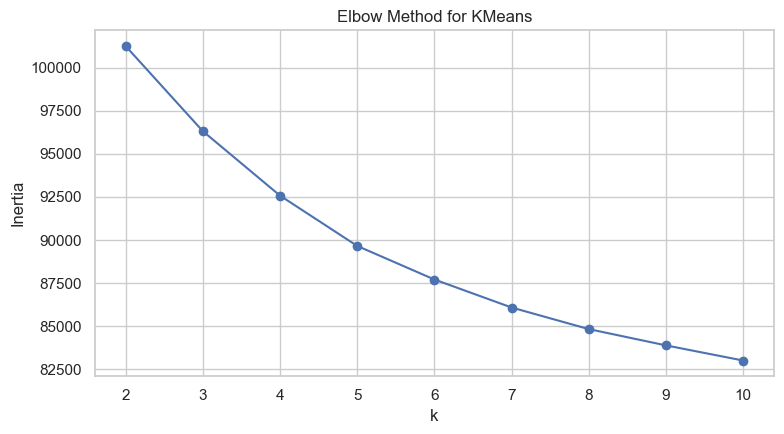

In [15]:
# Keep plots consistent across the notebook.
sns.set_theme(style='whitegrid')

# KMeans baseline comparison plots
plt.figure(figsize=(8, 4.5))
plt.plot(k_values, inertias, marker='o')
plt.title('Elbow Method for KMeans')
plt.xlabel('k')
plt.ylabel('Inertia')
plt.tight_layout()
plt.show()


## Export summary

The exported report highlights the KMeans-only family winners and compares them with the same internal metrics used in the notebook.

It is intended as a compact summary for sharing the KMeans baseline results without the broader non-KMeans experiment families.
